# 01 — First Quantum Circuit

This notebook introduces the basic workflow of quantum programming using Qiskit.

We will:

1. Create a quantum circuit
2. Apply a Hadamard gate
3. Create a superposition
4. Visualize the circuit
5. Simulate quantum measurements
6. Analyze the measurement probabilities

### Key Concept

A Hadamard gate transforms the computational basis state:

$$
|0\rangle
$$

into an equal superposition:

$$
|+\rangle =
\frac{|0\rangle + |1\rangle}{\sqrt{2}}
$$

Therefore, measuring the qubit gives approximately:

$$
P(0) = 50\%
$$

and

$$
P(1) = 50\%
$$

In [9]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

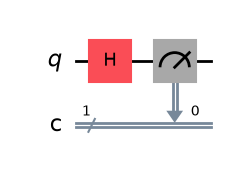

In [10]:
qc = QuantumCircuit(1, 1)

qc.h(0)

qc.measure(0, 0)

qc.draw("mpl")

In [11]:
simulator = AerSimulator()

job = simulator.run(qc, shots=1024)

result = job.result()

counts = result.get_counts()

print("Measurement Results:")
print(counts)

Measurement Results:
{'1': 503, '0': 521}


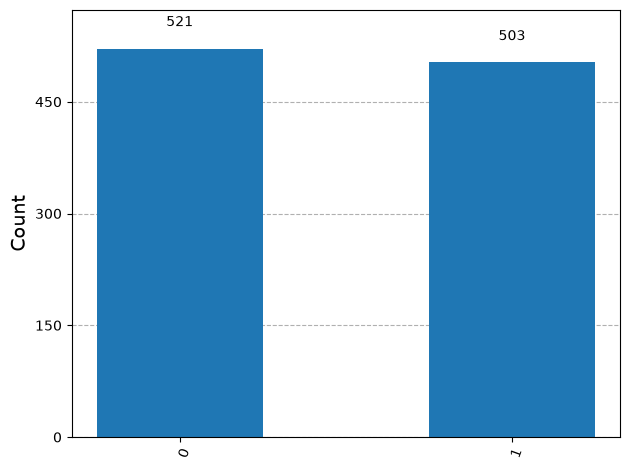

In [16]:
fig = plot_histogram(counts)
display(fig)

## Understanding the Quantum State

The Hadamard gate transforms the initial state:

$$
|0\rangle
$$

into:

$$
|+\rangle =
\frac{|0\rangle + |1\rangle}{\sqrt{2}}
$$

Therefore, the theoretical probabilities are:

$$
P(0)=\frac{1}{2}=50\%
$$

$$
P(1)=\frac{1}{2}=50\%
$$

We can verify this using Qiskit's `Statevector`.

In [17]:
from qiskit.quantum_info import Statevector

# Create a circuit without measurement
state_qc = QuantumCircuit(1)

# Apply Hadamard gate
state_qc.h(0)

# Calculate the quantum state
state = Statevector.from_instruction(state_qc)

print("Quantum State:")
print(state)

print("\nProbabilities:")
print(state.probabilities_dict())

Quantum State:
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))

Probabilities:
{np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}


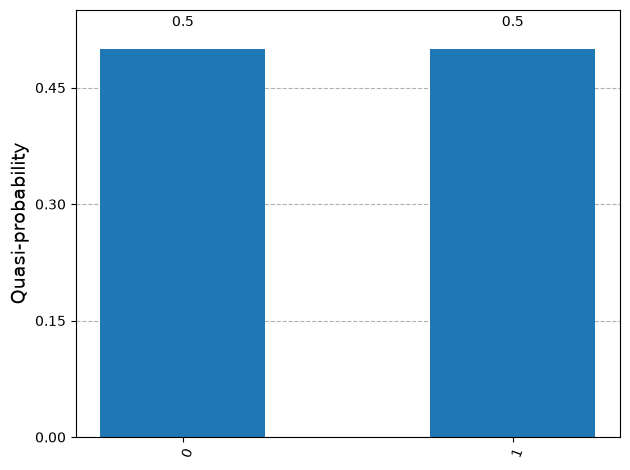

In [18]:
probabilities = state.probabilities_dict()

plot_histogram(probabilities)

## Experiment: Hadamard vs X Gate

Let's compare two different quantum gates.

### Hadamard Gate

The Hadamard gate creates an equal superposition:

$$
|0\rangle \rightarrow
\frac{|0\rangle + |1\rangle}{\sqrt{2}}
$$

Therefore:

$$
P(0)=50\%, \qquad P(1)=50\%
$$

### X Gate

The X gate behaves like a classical NOT operation:

$$
|0\rangle \rightarrow |1\rangle
$$

Therefore:

$$
P(0)=0\%, \qquad P(1)=100\%
$$

Let's verify this using Qiskit.

Hadamard State:
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))

Hadamard Probabilities:
{np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}


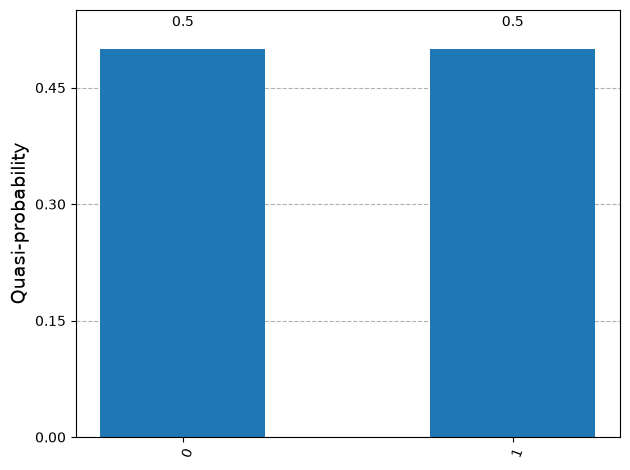

In [20]:
h_circuit = QuantumCircuit(1)

h_circuit.h(0)

h_state = Statevector.from_instruction(h_circuit)

print("Hadamard State:")
print(h_state)

print("\nHadamard Probabilities:")
print(h_state.probabilities_dict())

plot_histogram(h_state.probabilities_dict())

X Gate State:
Statevector([0.+0.j, 1.+0.j],
            dims=(2,))

X Gate Probabilities:
{np.str_('1'): np.float64(1.0)}


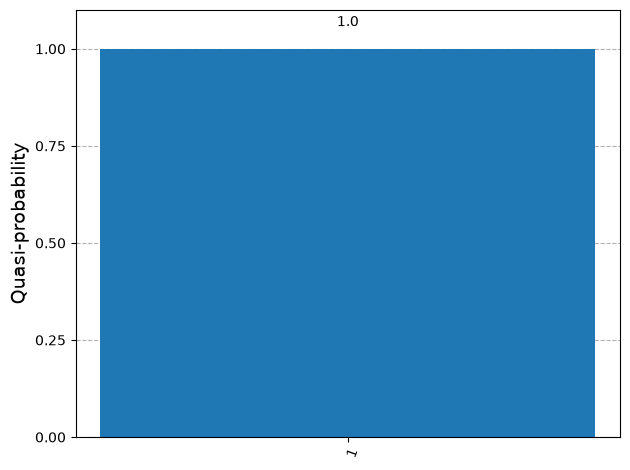

In [21]:
x_circuit = QuantumCircuit(1)

x_circuit.x(0)

x_state = Statevector.from_instruction(x_circuit)

print("X Gate State:")
print(x_state)

print("\nX Gate Probabilities:")
print(x_state.probabilities_dict())

plot_histogram(x_state.probabilities_dict())

## Key Takeaways

- A quantum circuit consists of quantum gates and measurements.
- The Hadamard gate creates an equal superposition from $|0\rangle$.
- A qubit in the state $|+\rangle$ has equal probabilities of being measured as 0 or 1.
- The X gate transforms $|0\rangle$ into $|1\rangle$.
- Statevector amplitudes determine measurement probabilities.
- Simulator shots produce statistical results that approach the theoretical probabilities as the number of shots increases.

### Core Workflow

**Quantum State → Quantum Gates → Measurement → Probability Distribution**